# 4.4 Automatic correction

4.4 Automatic correction: apply auto_correct to ev0..ev4 (no per-image
parameters), report pairwise W1 distances before/after, and output luma
std/1st-99th percentile ranges (to catch a degenerate constant-output
"solution"). Includes the ev3/ev4 failure case discussion data.

In [2]:
import sys
from pathlib import Path
from itertools import combinations

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [4]:
sys.path.insert(0, str(Path.cwd()))
from starter import auto_correct, hist, wasserstein1

ROOT = Path.cwd().parents[1]

In [5]:
def luma(rgb):
    rgb = rgb.astype(np.float64)
    return np.round(0.299 * rgb[..., 0] + 0.587 * rgb[..., 1] + 0.114 * rgb[..., 2]).astype(np.uint8)

In [6]:
originals = [np.asarray(Image.open(ROOT / f"images/p4/exposure/ev{i}.png")) for i in range(5)]
corrected = [auto_correct(im) for im in originals]

Y_before = [luma(im) for im in originals]
Y_after = [luma(im) for im in corrected]

In [7]:
h_before = [hist(y) for y in Y_before]
h_after = [hist(y) for y in Y_after]

pairs = list(combinations(range(5), 2))
w1_before = [wasserstein1(h_before[i], h_before[j]) for i, j in pairs]
w1_after = [wasserstein1(h_after[i], h_after[j]) for i, j in pairs]

In [8]:
print("Pairwise W1 distances (10 pairs):")
for (i, j), wb, wa in zip(pairs, w1_before, w1_after):
    print(f"  ev{i}-ev{j}: before={wb:8.3f}  after={wa:8.3f}")
print(f"\nmean W1 before={np.mean(w1_before):.3f}  after={np.mean(w1_after):.3f}")
print(f"max  W1 before={np.max(w1_before):.3f}  after={np.max(w1_after):.3f}")

Pairwise W1 distances (10 pairs):
  ev0-ev1: before=  28.906  after=   0.542
  ev0-ev2: before=  86.632  after=   0.769
  ev0-ev3: before= 143.018  after=  53.980
  ev0-ev4: before= 165.311  after=  76.273
  ev1-ev2: before=  57.726  after=   0.336
  ev1-ev3: before= 114.112  after=  53.461
  ev1-ev4: before= 136.404  after=  75.753
  ev2-ev3: before=  56.386  after=  53.247
  ev2-ev4: before=  78.679  after=  75.539
  ev3-ev4: before=  22.293  after=  22.293

mean W1 before=88.947  after=41.219
max  W1 before=165.311  after=76.273


In [9]:
print("\nOutput luma statistics (checking against degenerate constant output):")
for i in range(5):
    y = Y_after[i]
    p1, p99 = np.percentile(y, [1, 99])
    print(f"  ev{i}: std={y.std():.2f}  p1-p99=[{p1:.0f},{p99:.0f}]  range={p99-p1:.0f}")


Output luma statistics (checking against degenerate constant output):
  ev0: std=77.26  p1-p99=[0,254]  range=254
  ev1: std=77.24  p1-p99=[0,253]  range=253
  ev2: std=77.12  p1-p99=[0,254]  range=254
  ev3: std=97.14  p1-p99=[0,255]  range=255
  ev4: std=95.51  p1-p99=[0,255]  range=255


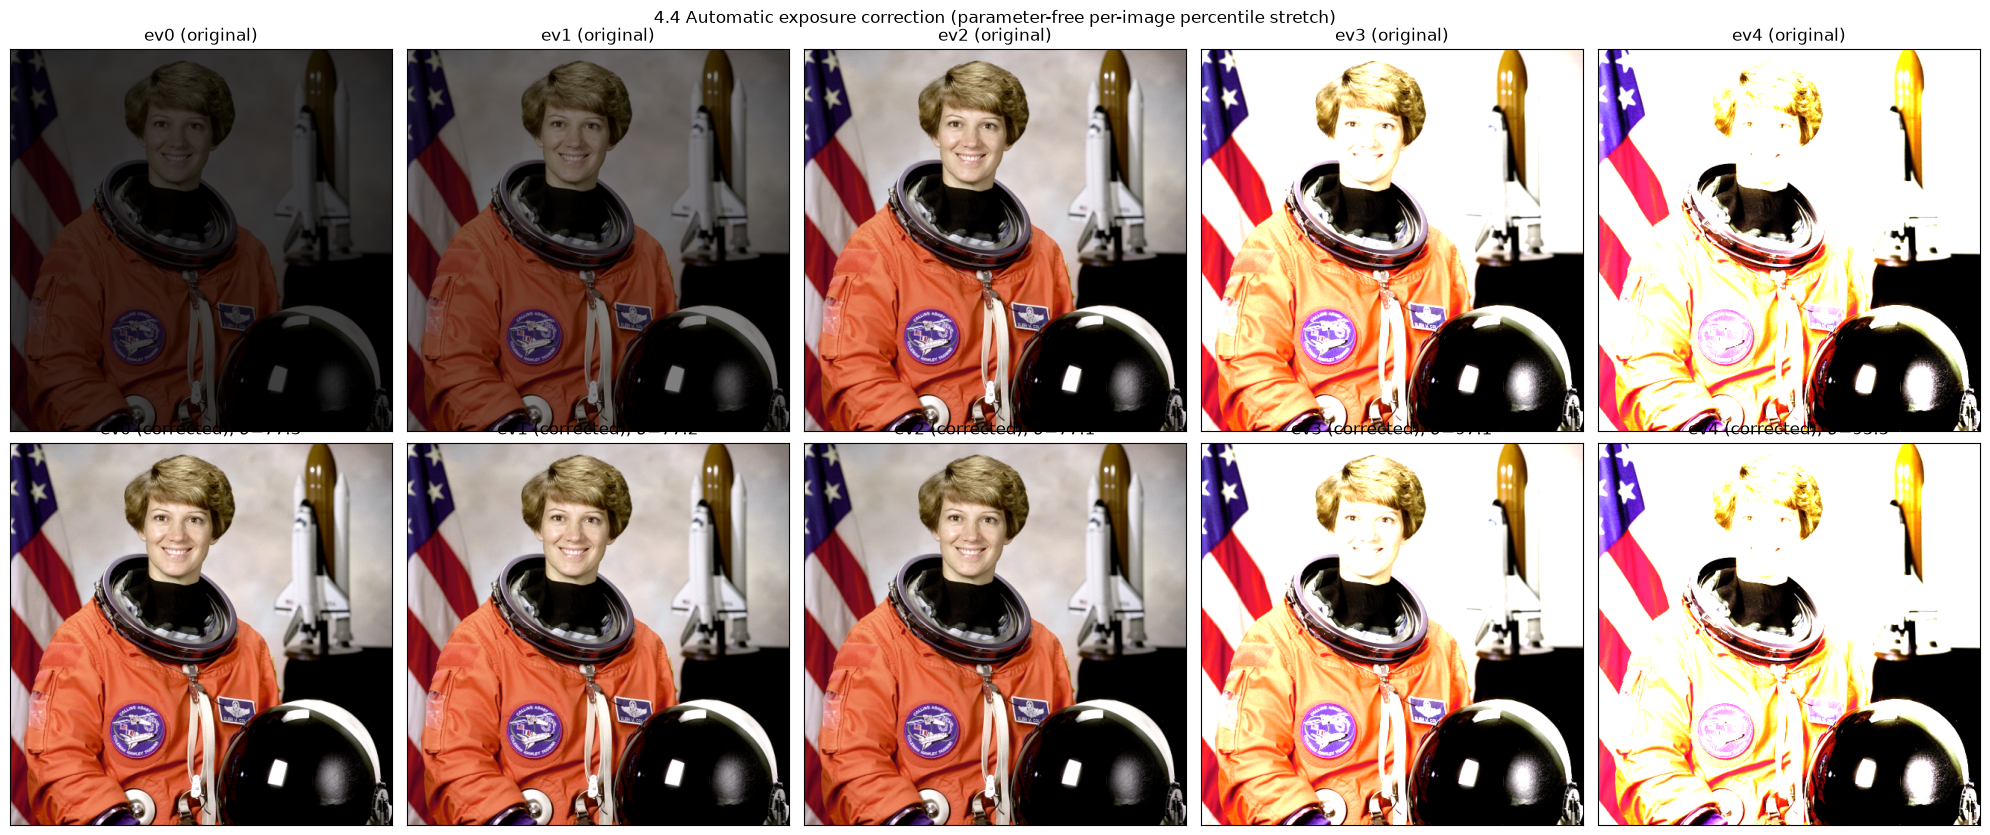

In [10]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8.5))
for i in range(5):
    axes[0, i].imshow(originals[i])
    axes[0, i].set_title(f"ev{i} (original)")
    axes[0, i].set_xticks([]); axes[0, i].set_yticks([])
    axes[1, i].imshow(corrected[i])
    std_ = Y_after[i].std()
    axes[1, i].set_title(f"ev{i} (corrected), $\\sigma$={std_:.1f}")
    axes[1, i].set_xticks([]); axes[1, i].set_yticks([])
fig.suptitle("4.4 Automatic exposure correction (parameter-free per-image percentile stretch)")
fig.tight_layout()
plt.show()

In [11]:
# W1 table
print(f"{'Pair':10s} {'W1 before':>10s} {'W1 after':>10s}")
for (i, j), wb, wa in zip(pairs, w1_before, w1_after):
    print(f"ev{i}--ev{j}   {wb:10.3f} {wa:10.3f}")
print(f"{'Mean':10s} {np.mean(w1_before):10.3f} {np.mean(w1_after):10.3f}")
print(f"{'Max':10s} {np.max(w1_before):10.3f} {np.max(w1_after):10.3f}")

Pair        W1 before   W1 after
ev0--ev1       28.906      0.542
ev0--ev2       86.632      0.769
ev0--ev3      143.018     53.980
ev0--ev4      165.311     76.273
ev1--ev2       57.726      0.336
ev1--ev3      114.112     53.461
ev1--ev4      136.404     75.753
ev2--ev3       56.386     53.247
ev2--ev4       78.679     75.539
ev3--ev4       22.293     22.293
Mean           88.947     41.219
Max           165.311     76.273


In [12]:
print(f"\n{'Image':6s} {'Output luma std':>16s} {'1st pct':>8s} {'99th pct':>9s}")
for i in range(5):
    y = Y_after[i]
    p1, p99 = np.percentile(y, [1, 99])
    print(f"ev{i:<4d} {y.std():16.2f} {p1:8.0f} {p99:9.0f}")


Image   Output luma std  1st pct  99th pct
ev0               77.26        0       254
ev1               77.24        0       253
ev2               77.12        0       254
ev3               97.14        0       255
ev4               95.51        0       255
